In [1]:
from utils.file_utils import FileUtils
from utils.analysis_util import AnalysisUtil
from utils.config_utils import DataConfig
import pandas as pd
from utils.data_utils import DataUtils
from utils.plot_utils import PlotUtils
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = FileUtils.read_csv_file(DataConfig.FilePath)

In [5]:
print(data.shape)

(59970015, 7)


In [3]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)
F = suite2p_data['F']
iscell = suite2p_data['iscell']
iscell_df = pd.DataFrame(iscell)
filtered_iscell = DataUtils.filter_rows_by_threshold( iscell_df, column=0, threshold=1, operator="==")
F_subset = F[filtered_iscell.index]

In [6]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)
F = suite2p_data['F']
F_tone_puff = F[:, -68000:]
print(F_tone_puff.shape)
suite2p_data['F'] = F_tone_puff
print(suite2p_data['F'].shape)

(1052, 68000)
(1052, 68000)


In [2]:
FileUtils.write_mat_file("/Users/yuchang/Downloads/m4d1/Fall1.mat", suite2p_data)

NameError: name 'suite2p_data' is not defined

In [3]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)
F = suite2p_data['F']
print(F.shape)

(1052, 68000)


In [114]:
trails = FileUtils.read_csv_file(DataConfig.TrailsPath)
tones = trails["tone_onset_index"].iloc[0:2].to_numpy()

In [115]:
mean_F = DataUtils.calculate_mean(F_subset, axis = 0)
plotting = mean_F[1:1500]

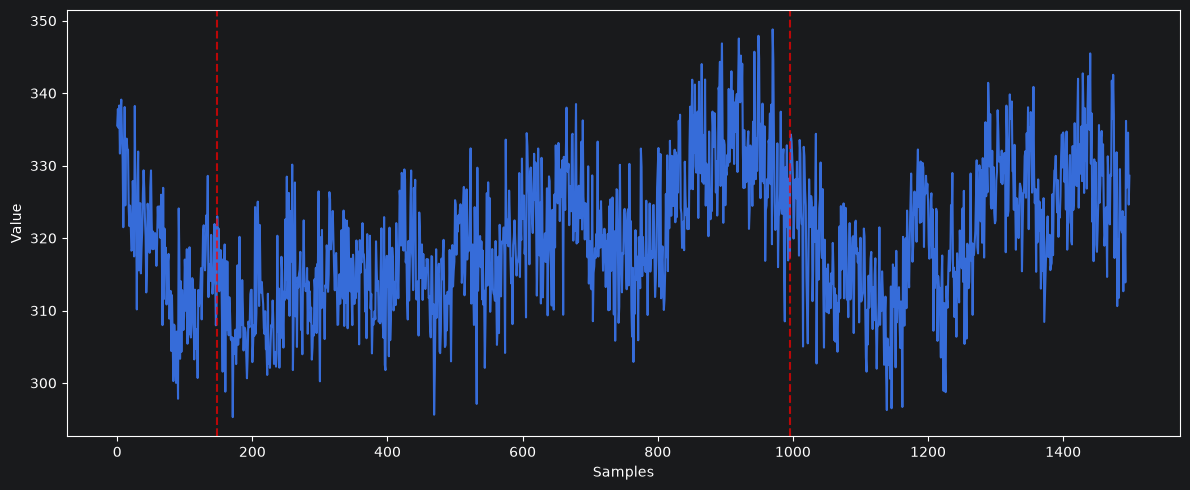

In [116]:
PlotUtils.draw_line_plot(plotting, vlines = tones)

In [93]:
filtered = FileUtils.read_csv_file("/Users/yuchang/Desktop/research/DataAlign/files/m3d1/m3d1_filtered_reindexed.csv")

In [100]:
differences = filtered["Time(ms)"].diff()

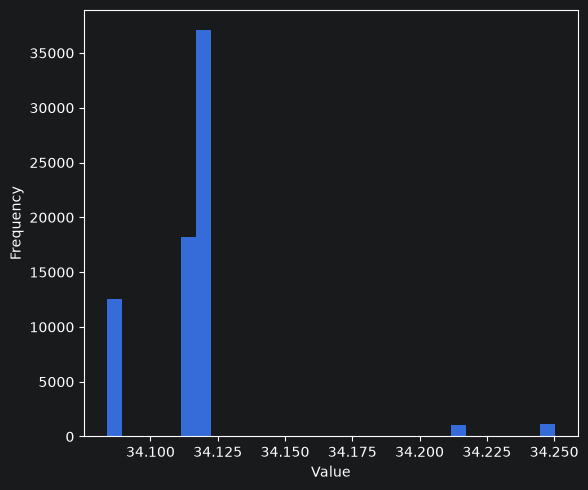

In [101]:
PlotUtils.draw_histogram(differences)

In [53]:
trials_df = FileUtils.read_csv_file(DataConfig.TrailsPath)
data_trials, extracted_trials, relative_frames = AnalysisUtil.extract_trial_data(
        F_subset, trials_df, trial_length=31, pre_frames=0, post_frames=50)

In [54]:
p = DataUtils.calculate_mean(data_trials, axis = 1)

In [55]:
q = DataUtils.calculate_mean(DataUtils.calculate_mean(data_trials, axis = 1), axis = 0)

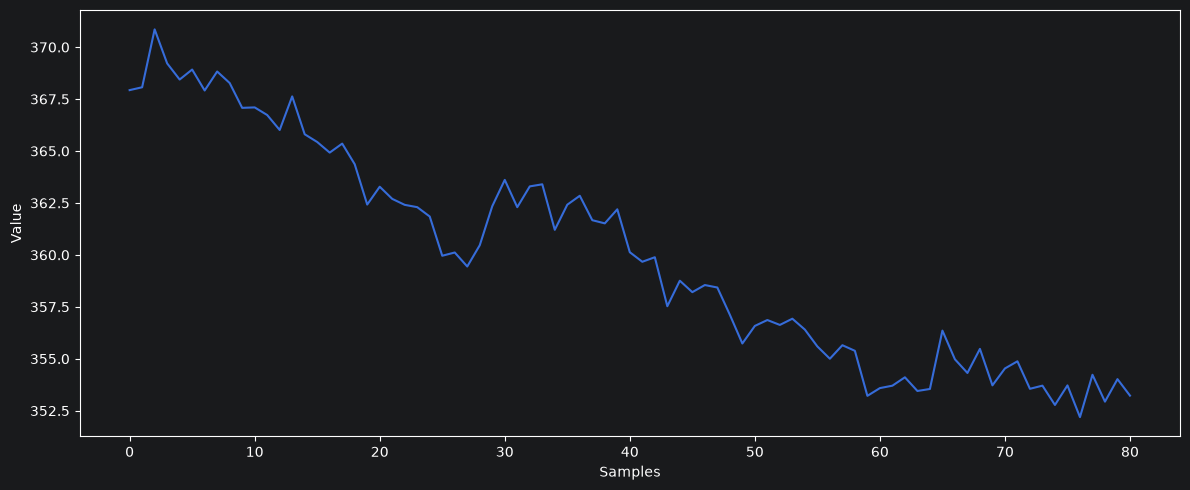

In [56]:
PlotUtils.draw_line_plot(q)

In [45]:
p.shape

(65, 51)

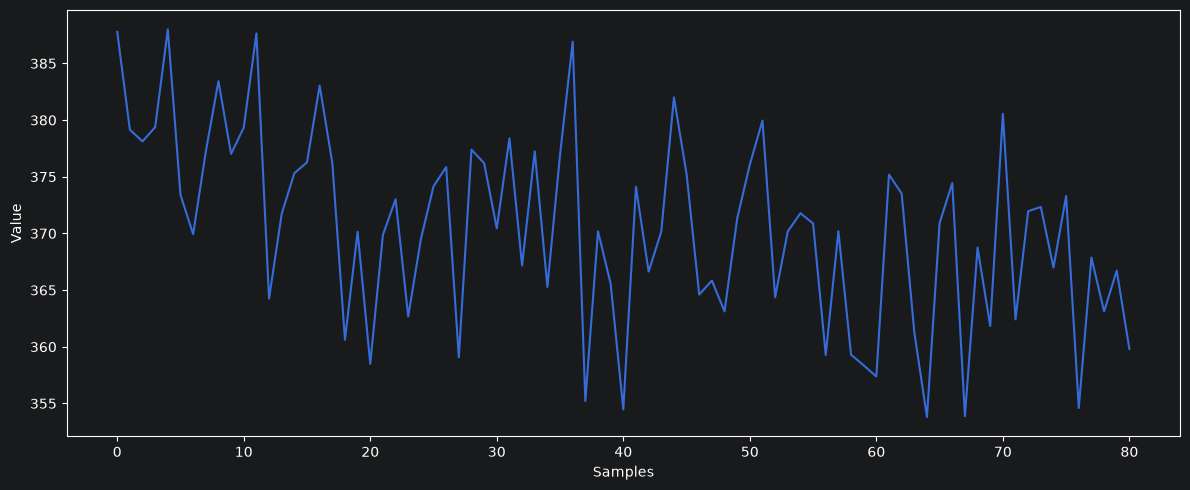

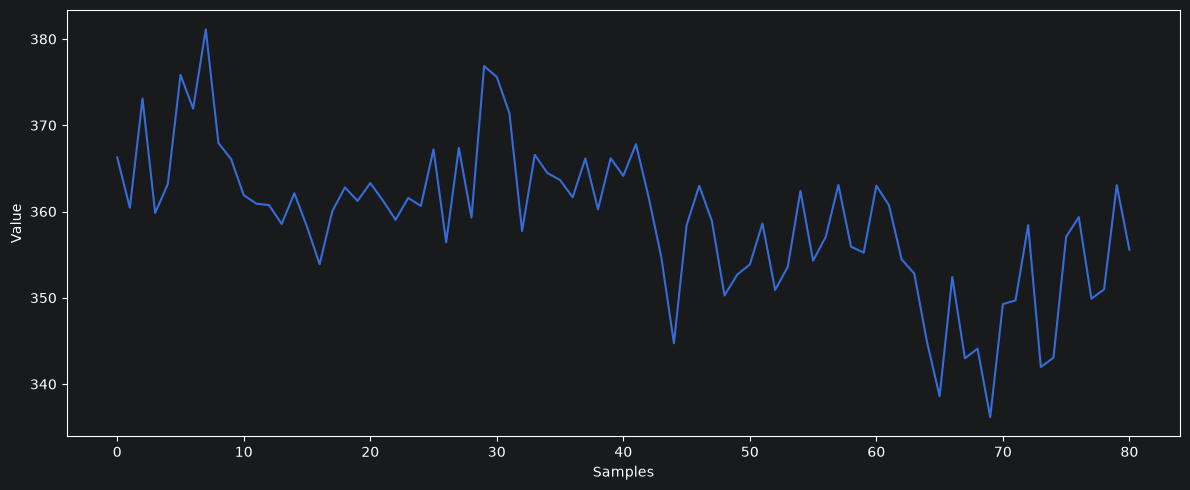

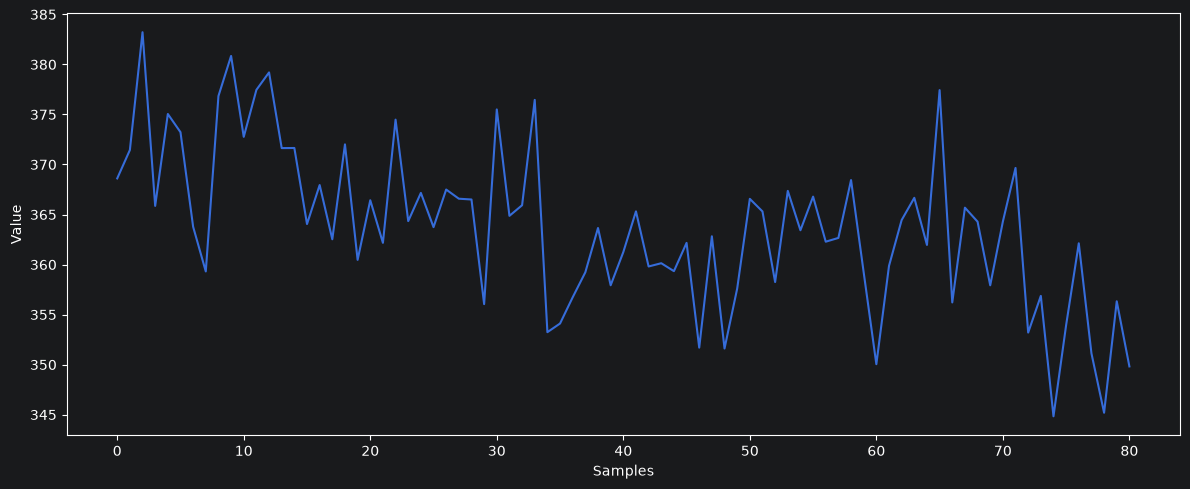

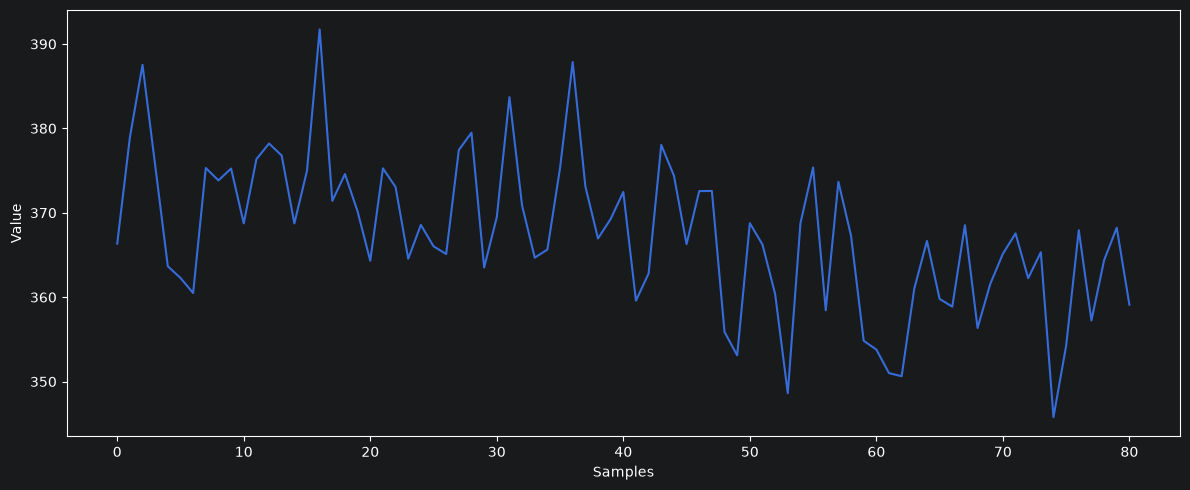

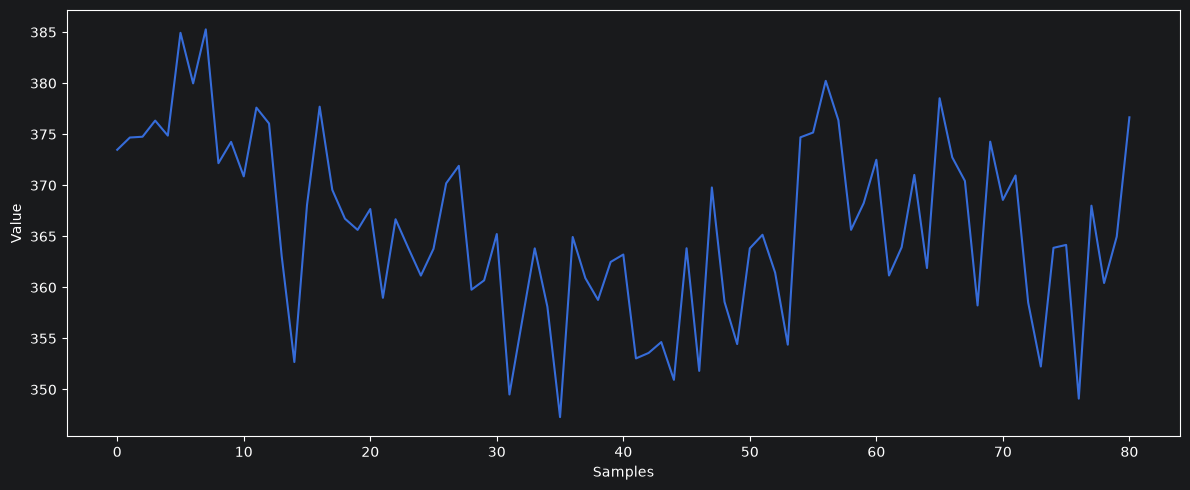

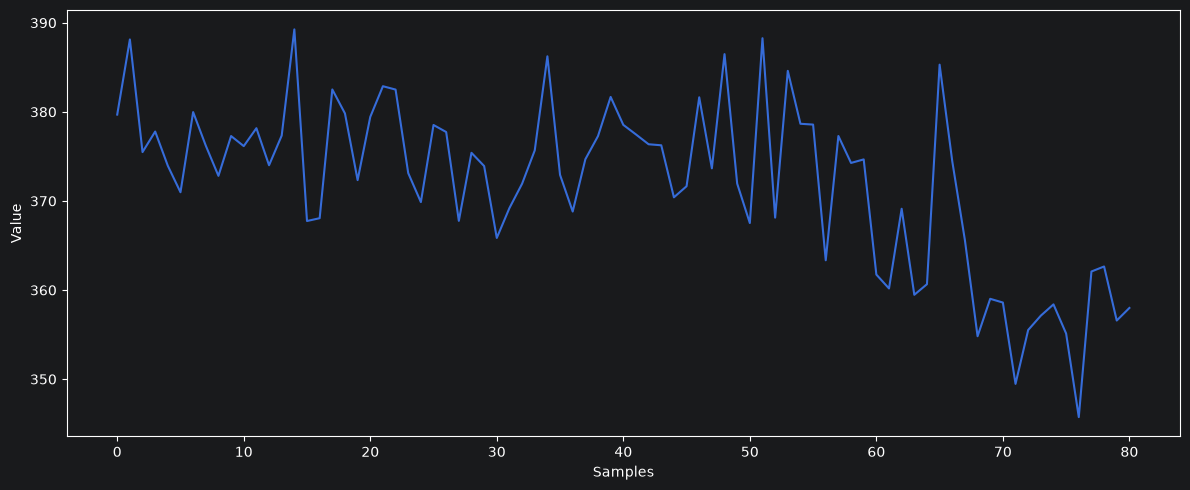

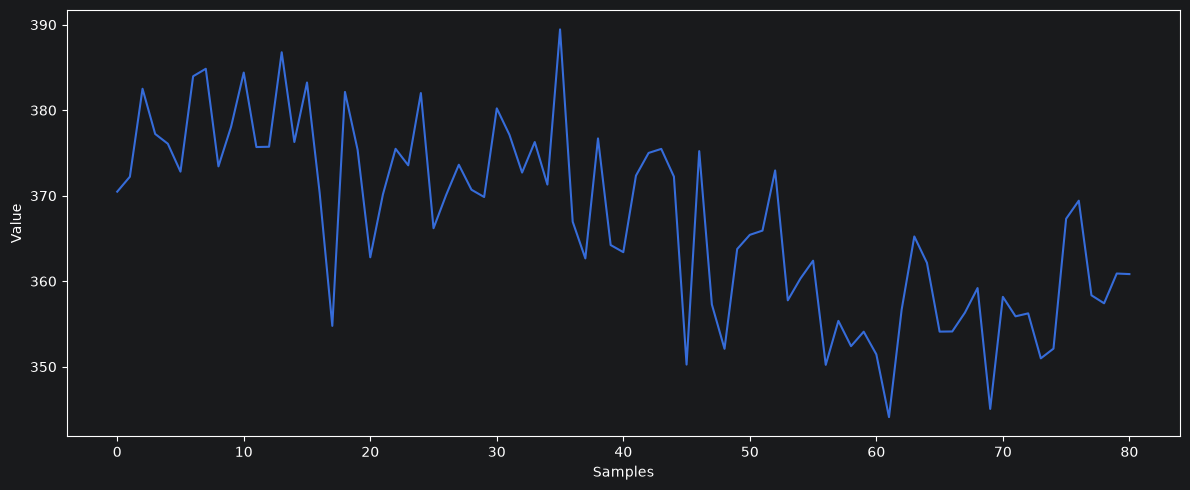

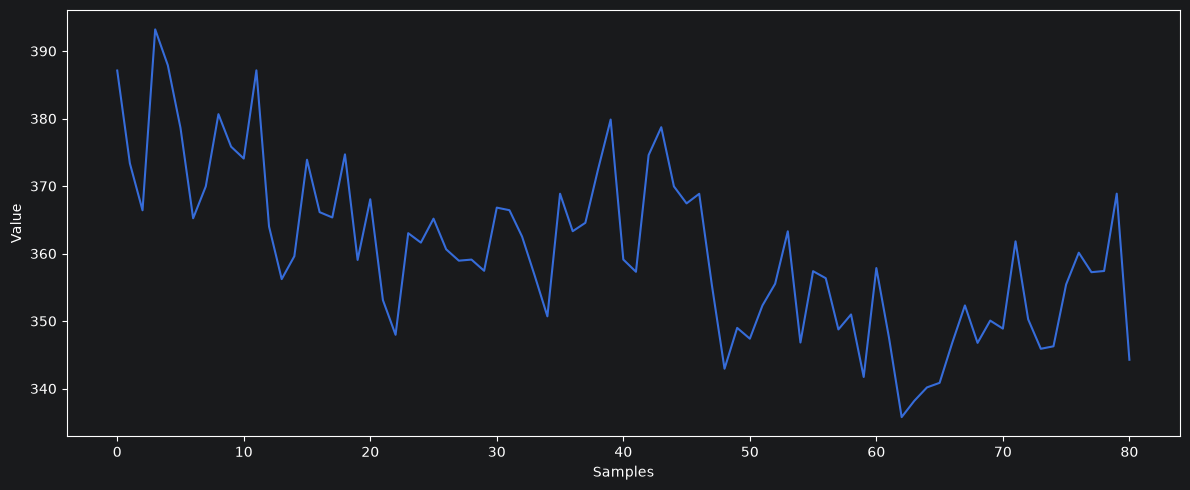

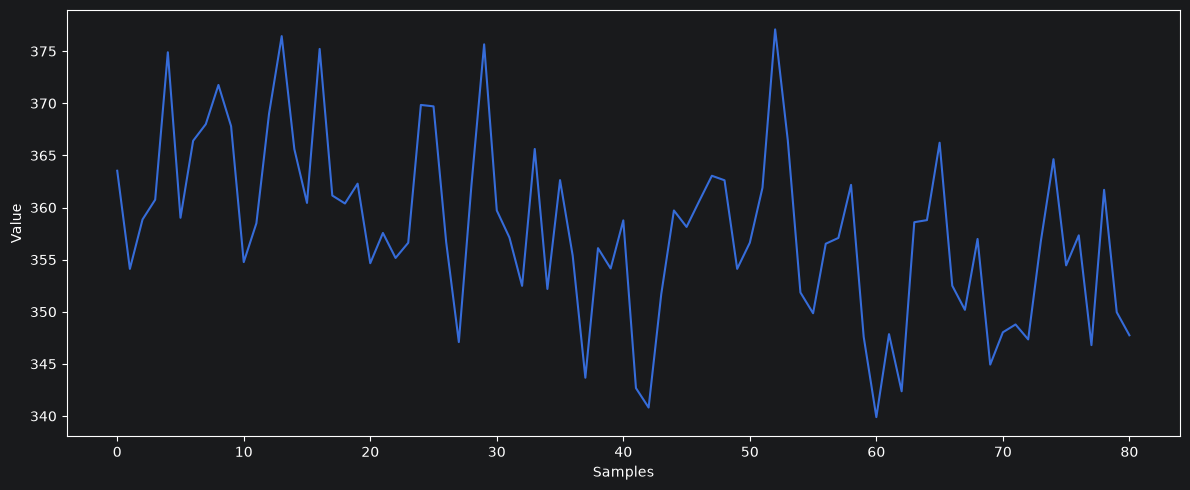

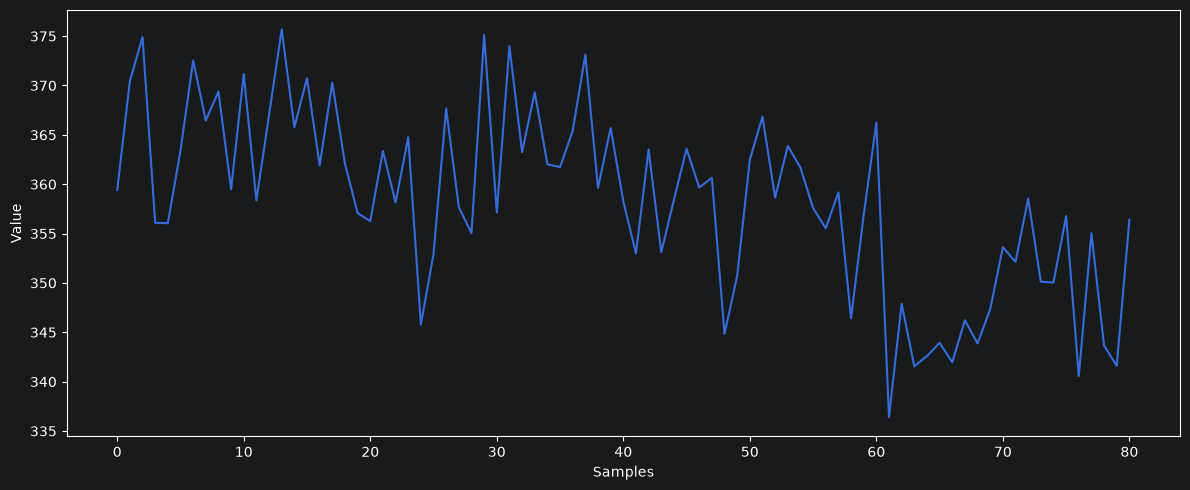

In [57]:
for i in range(10):
    PlotUtils.draw_line_plot(p[i+20])

In [11]:
data_trials.shape

(64, 340, 1031)

In [8]:
data = FileUtils.read_npz_file(DataConfig.DffTrailPath)
dff = data["dff"]
dff.shape

(65, 155, 51)

In [3]:
data.shape

(155, 70000)

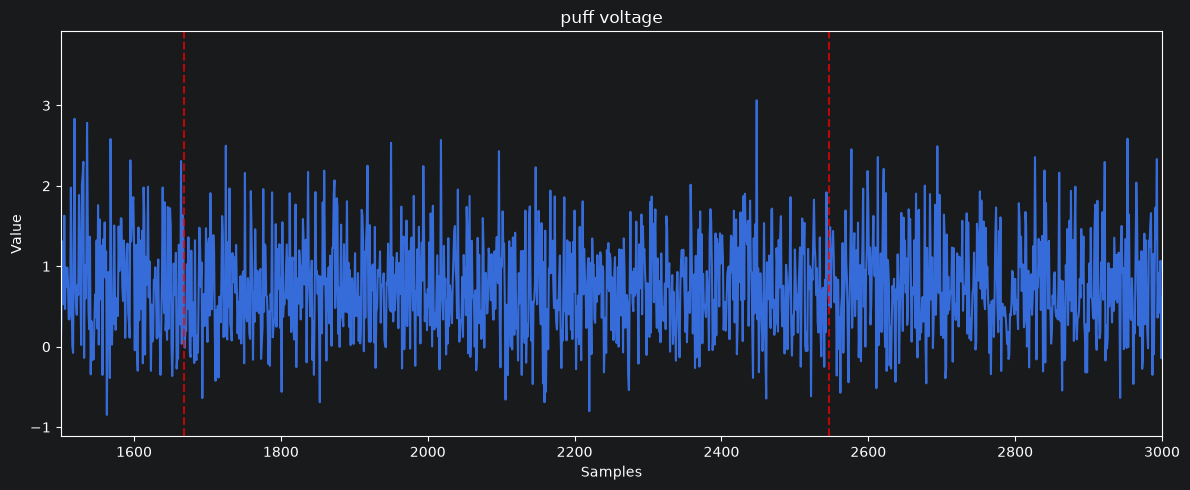

In [7]:
PlotUtils.draw_line_plot(
    data.iloc[10,:],
    x_label="Samples",
    y_label="Value",
    title="puff voltage",
    x_start=1500,
    x_stop=3000,
    vlines=[1668, 2546],
)

In [13]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)
F = suite2p_data['F']

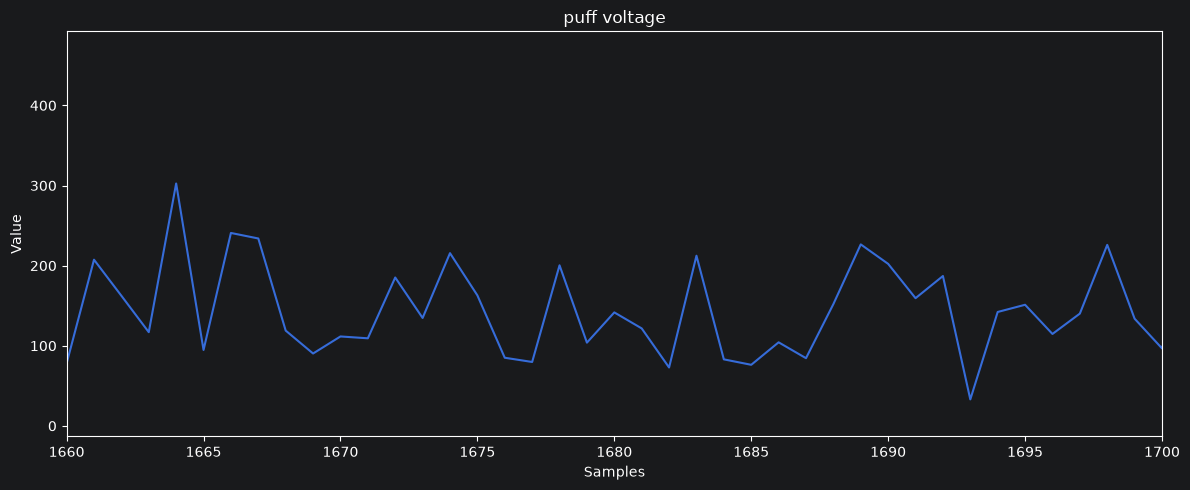

In [19]:
PlotUtils.draw_line_plot(
    F[10],
    x_label="Samples",
    y_label="Value",
    title="puff voltage",
    x_start=1660,
    x_stop=1700
)

In [11]:
dff = FileUtils.read_npz_file(DataConfig.DffTrailPath)

In [12]:
dff["dff"].shape

(65, 340, 51)

In [9]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)

F = suite2p_data['F']

In [10]:
F

array([[657.0394  , 517.8347  , 448.47244 , ..., 443.0866  , 414.93698 ,
        414.12598 ],
       [213.44739 , 270.6842  , 322.76315 , ..., 235.13159 , 180.47368 ,
        444.18423 ],
       [153.65625 , 114.09375 , 245.65625 , ..., 122.78125 ,  11.09375 ,
         29.21875 ],
       ...,
       [ 67.67941 , 152.32773 , 133.82465 , ...,  82.13699 , 128.14328 ,
         71.256454],
       [ 35.085396, 131.22354 , 117.34248 , ...,  58.36384 ,  49.1206  ,
        255.62462 ],
       [ 38.26306 ,  20.384624,  92.79108 , ...,  70.13132 ,  37.848354,
         17.16806 ]], shape=(609, 70000), dtype=float32)

In [38]:
data = np.load("/Users/yuchang/Downloads/m6d2_dff_trails.npz")
no_puff_trials = [1, 2, 3, 4, 5, 15, 25, 35, 45, 55, 63]
dff = data["dff"]
relative_frames = data["relative_frames"]

# Convert 1-based trial numbers to 0-based indices
no_puff_indices = np.array(no_puff_trials) - 1

# All trial indices
all_indices = np.arange(dff.shape[0])

# Trials that DO have a puff
puff_indices = np.setdiff1d(
    all_indices,
    no_puff_indices
)

dff_no_puff = dff[no_puff_indices]
dff_puff = dff[puff_indices]

In [39]:
print("Total trials:", dff.shape[0])
print("No-puff trials:", no_puff_indices)
print("Puff trials:", puff_indices)

print("Number of no-puff trials:", len(no_puff_indices))
print("Number of puff trials:", len(puff_indices))

Total trials: 65
No-puff trials: [ 0  1  2  3  4 14 24 34 44 54 62]
Puff trials: [ 5  6  7  8  9 10 11 12 13 15 16 17 18 19 20 21 22 23 25 26 27 28 29 30
 31 32 33 35 36 37 38 39 40 41 42 43 45 46 47 48 49 50 51 52 53 55 56 57
 58 59 60 61 63 64]
Number of no-puff trials: 11
Number of puff trials: 54


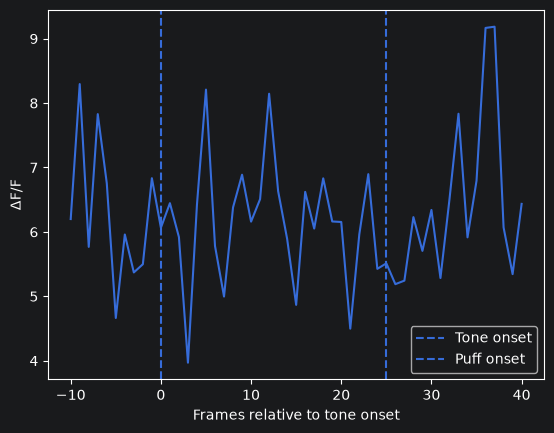

In [66]:
neuron = 12

mean_response = np.nanmean(
    dff_puff[:, neuron, :],
    axis=0
)

plt.plot(relative_frames, mean_response)

plt.axvline(0, linestyle="--", label="Tone onset")
plt.axvline(25, linestyle="--", label="Puff onset")

plt.xlabel("Frames relative to tone onset")
plt.ylabel("ΔF/F")
plt.legend()
plt.show()

In [68]:
mean_dff = np.nanmean(dff_puff, axis=0)

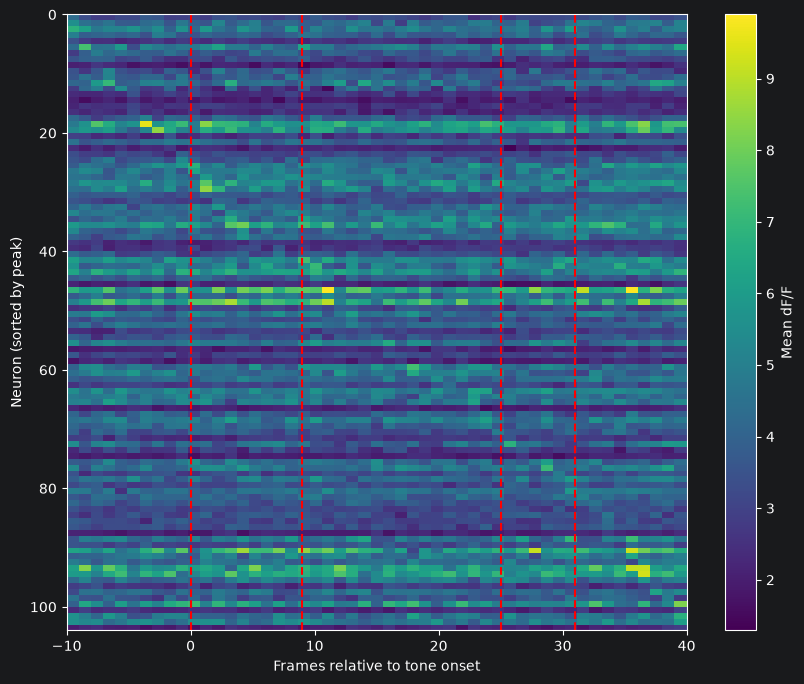

In [78]:
# Calculate the average ΔF/F for each neuron across all frames
neuron_mean_dff = np.nanmean(mean_dff, axis=1)

# Keep only neurons with average ΔF/F >= 2
keep = neuron_mean_dff >= 2

filtered_dff = mean_dff[keep]

# Find the frame of maximum ΔF/F for each remaining neuron
peak_frames = np.nanargmax(filtered_dff, axis=1)

# Sort neurons by peak location
sort_idx = np.argsort(peak_frames)

# Reorder the heatmap
sorted_dff = filtered_dff[sort_idx]

# Plot
plt.figure(figsize=(10, 8))

plt.imshow(
    sorted_dff,
    aspect="auto",
    extent=[
        relative_frames[0],
        relative_frames[-1],
        sorted_dff.shape[0],
        0
    ]
)

plt.axvline(0, linestyle="--", color="red", label="Tone onset")
plt.axvline(9, linestyle="--", color="red", label="ISI start")
plt.axvline(25, linestyle="--", color="red", label="Puff onset")
plt.axvline(31, linestyle="--", color="red", label="Trial end")

plt.xlabel("Frames relative to tone onset")
plt.ylabel("Neuron (sorted by peak)")
plt.colorbar(label="Mean dF/F")

plt.show()

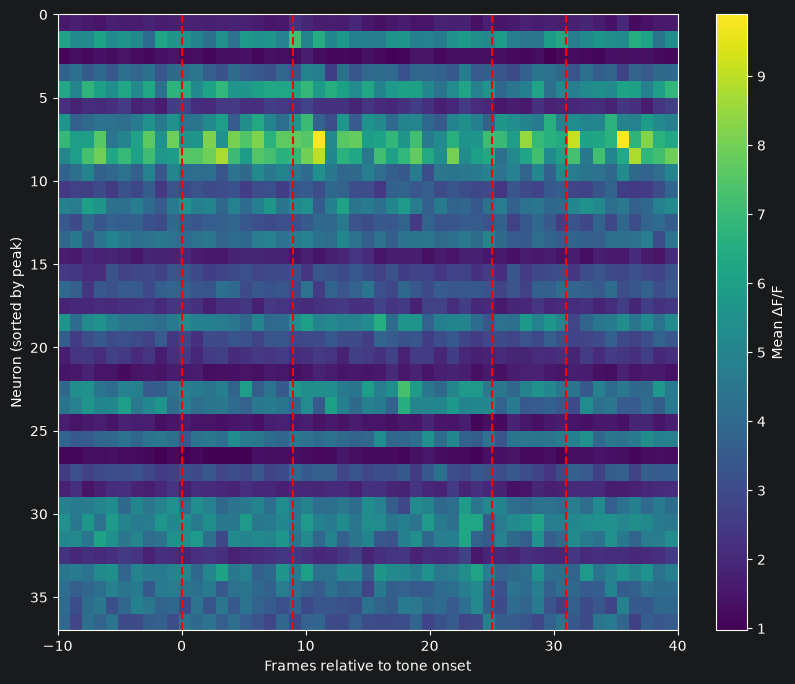

In [94]:
# Find peak frame for each neuron across the entire trial
peak_frames = np.nanargmax(mean_dff, axis=1)

# Keep neurons whose peak occurs during the ISI
isi_neurons = (peak_frames >= 19) & (peak_frames <= 35)

# Keep only those neurons
isi_peak_dff = mean_dff[isi_neurons]

# Get their peak frames
isi_peak_frames = peak_frames[isi_neurons]

# Sort neurons by when their peak occurs
sort_idx = np.argsort(isi_peak_frames)

sorted_dff = isi_peak_dff[sort_idx]
sorted_peak_frames = isi_peak_frames[sort_idx]
plt.figure(figsize=(10, 8))

plt.imshow(
    sorted_dff,
    aspect="auto",
    extent=[
        relative_frames[0],
        relative_frames[-1],
        sorted_dff.shape[0],
        0
    ]
)

plt.axvline(0, linestyle="--", color="red", label="Tone onset")
plt.axvline(9, linestyle="--", color="red", label="ISI start")
plt.axvline(25, linestyle="--", color="red", label="Puff onset")
plt.axvline(31, linestyle="--", color="red", label="Trial end")

plt.xlabel("Frames relative to tone onset")
plt.ylabel("Neuron (sorted by peak)")
plt.colorbar(label="Mean ΔF/F")

plt.show()

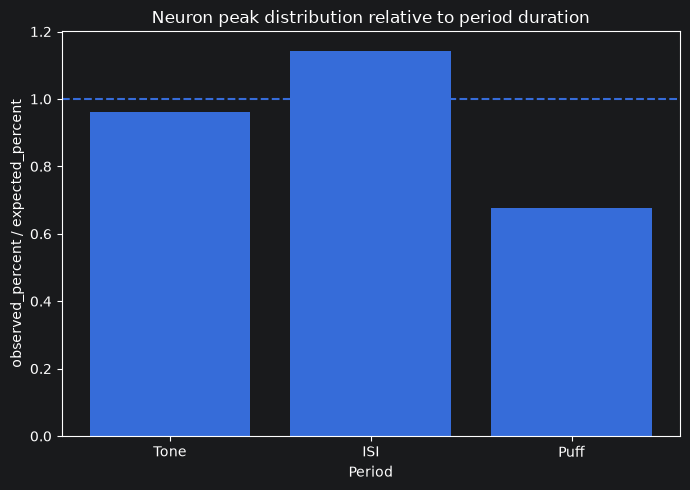

In [104]:
import numpy as np
import matplotlib.pyplot as plt

peak_frames = np.nanargmax(mean_dff, axis=1)

periods = {
    "Tone": (10, 19),
    "ISI": (19, 35),
    "Puff": (35, 41)
}

total_frames = 31
n_neurons = np.sum(
        (peak_frames >= 10) &
        (peak_frames < 41)
    )

enrichment = {}

for name, (start, end) in periods.items():

    duration = end - start

    # Number of neurons whose peak falls in this period
    n_peaks = np.sum(
        (peak_frames >= start) &
        (peak_frames < end)
    )

    observed_percent = n_peaks / n_neurons * 100

    # Expected percentage if peaks were uniformly distributed over time
    expected_percent = duration / total_frames * 100

    enrichment[name] = observed_percent / expected_percent

# Plot
plt.figure(figsize=(7, 5))

plt.bar(
    enrichment.keys(),
    enrichment.values()
)

plt.axhline(
    1,
    linestyle="--",
    label="Expected based on duration"
)

plt.ylabel("observed_percent / expected_percent")
plt.xlabel("Period")
plt.title("Neuron peak distribution relative to period duration")

plt.tight_layout()
plt.show()

In [98]:
n_neurons

123

In [ ]:
no_puff_trials = [1, 2, 3, 4, 5, 15, 25, 35, 45, 55, 63]

In [3]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)

In [4]:
print(suite2p_data.keys())
F = suite2p_data['F']
iscell = suite2p_data['iscell']

dict_keys(['__header__', '__version__', '__globals__', 'stat', 'ops', 'F', 'Fneu', 'spks', 'iscell', 'redcell'])


In [11]:
iscell_df = pd.DataFrame(iscell)

filtered_iscell = DataUtils.filter_rows_by_threshold(
    iscell_df,
    column=1,
    threshold=0.7,
    operator=">"
)

filtered_iscell = DataUtils.filter_rows_by_threshold(
    filtered_iscell,
    column=0,
    threshold=1,
    operator="=="
)

F_subset = F[filtered_iscell.index]
F_subset

array([[ 59.149937, 218.01114 , 412.9315  , ..., 199.36597 , 331.58807 ,
        392.00455 ],
       [ 40.733803, 306.323   ,  73.488655, ..., 267.3479  , 161.02979 ,
         87.93715 ],
       [ 77.37945 , 118.85689 ,  76.18735 , ...,  24.538456, 216.31583 ,
         70.1959  ],
       ...,
       [  9.809528,  10.077004,  35.773903, ...,  15.529022,  44.962856,
         34.016533],
       [126.56187 , 251.27203 , 141.80942 , ...,  79.44999 ,  88.255325,
        177.73328 ],
       [ 12.307676,  13.781424, 107.559364, ...,  40.40319 , 112.46123 ,
         70.36949 ]], shape=(123, 64000), dtype=float32)

In [17]:
dff, f0 = AnalysisUtil.calculate_dff(F_subset, 30, window_seconds=30, percentile=10)

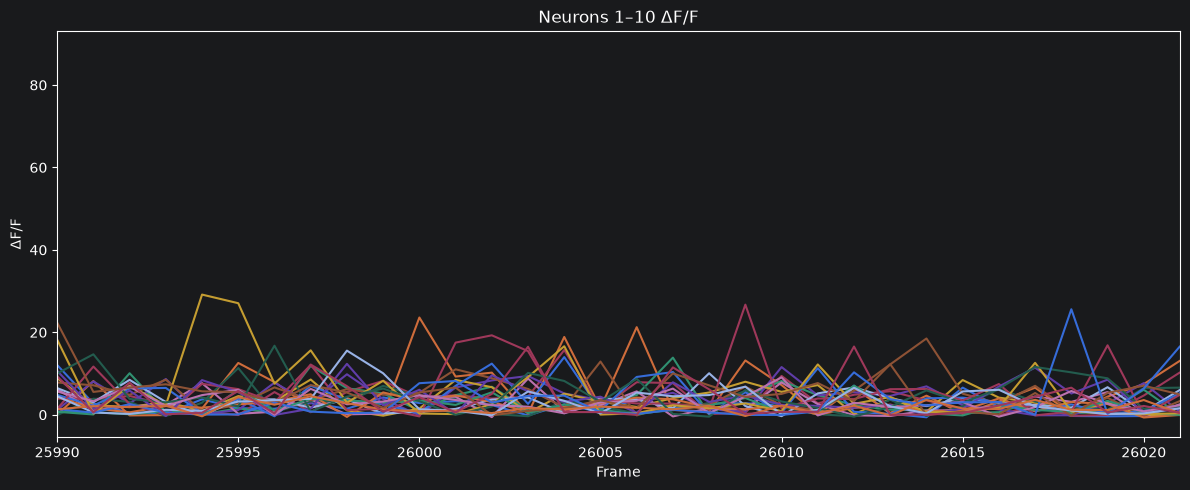

In [24]:
PlotUtils.draw_line_plot(
    dff[100:130],
    x_label="Frame",
    y_label="dF/F",
    title="Neurons 1–10 dF/F",
    x_start=25990,
    x_stop=26021
)